In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from util.static import PATH_OUTPUT, PATH_LABELING, PATH_FIGURES_DISTRIBUTIONS

# Data Visualization

This notebook contains the code to visualize the distribution of the labeled data (both the automatic and manual) on file (i.e., subflow) level.

## Data Preparation

Firstly, load the individual data sets and bring them into a shared format. There are three data sources to bring together:

1. The manually labeled data on sentence-level
2. The manually labeled data on subflow-level
3. The automatically labeled data on subflow-level

### Manually Labeled Data

The manually labeled data needs to be brought into a common format, i.e., the sentence-level labels need to be aggregated per subflow.

In [2]:
# determine the file name of the manually labeled data set
data_manual_filename: str = os.path.join(PATH_LABELING, 'rq4tlr-manual-variables.xlsx')

# load the manually labeled data sets on both the requirements (req) and sentences (sen) level
dfm_req = pd.read_excel(data_manual_filename, sheet_name='Requirements R2')
dfm_sen = pd.read_excel(data_manual_filename, sheet_name='Sentences R2')

# drop the "Comment" column from both data frames
dfm_req.drop(columns=['Comment', 'Inconsistent Level of Abstraction', 'Contains clarification'], inplace=True)
dfm_sen.drop(columns=['Comment'], inplace=True)

In [3]:
# specify the sentence-level variables that need to be aggregated
manual_sentence_variables: list[str] = [
    "Coordination Ambiguity", 
    "Contains UI Design Details", 
    "Contains Alternative", 
    "Inconsistent Level of Abstraction", 
    "Contains Clarification"]

# aggregate the rows of dfm_sen per Dataset and File column
dfm_sen_aggregated = dfm_sen.groupby(['Dataset', 'File'])[manual_sentence_variables].mean()
# reset the index of the aggregated data frame
dfm_sen_aggregated = dfm_sen_aggregated.reset_index()

In [4]:
# join the dfm_req and dfm_sen_aggregated data frames on the Dataset and File columns
dfm = dfm_req.merge(dfm_sen_aggregated, on=['Dataset', 'File'], how='left')

# make all strings in the dataset column lowercase
dfm['Dataset'] = dfm['Dataset'].str.lower()

In [5]:
# define the requirements-level variables that correspond to the column namens
manual_requirements_variables: list[str] = [
    "Functional Duplication", 
    "Use Case Naming Problems", 
    "Inappropriate Scope",
    "Incoherent Text Order",
    "Inputs or Outputs not quantified",
    "Contains NFRs",
    "Contains Actor-Actor Interaction",
    "Contains justifications"]

### Automatically labeled Data

Next, load the automatically labeled data (which is already harmonized on a subflow-level). This data set can be merged with the harmonized manually labeled data set.

In [6]:
# determine the file name of the automatically labeled data set
data_automatic_filename: str = os.path.join(PATH_OUTPUT, 'rq4tlr-automatic-aggregated.csv')

# load the data set
dfa: pd.DataFrame = pd.read_csv(data_automatic_filename)

# rename the dataset and file columns to match the manual data set
dfa.rename(columns={'dataset': 'Dataset', 'file': 'File'}, inplace=True)

In [7]:
# merge the manual and automatic data sets on the Dataset and File columns
df = dfm.merge(dfa, on=['Dataset', 'File'], how='left')

# save the merged data set
data_merged_filename: str = os.path.join(PATH_OUTPUT, 'rq4tlr-merged.csv')
df.to_csv(data_merged_filename, index=False)

In [8]:
# specify the automatically labeled variables and categorize them by their respective type
automatic_variables: dict[str, list[str]] = {
    "boolean": ["happy_ucs", "meaningless_uc", "tangled_requirements", "scattered_requirements", "nfrs", "anaphora", "optional", "starts_without_nounphrase", "incomplete_comparisons", "passive", "negation"],
    "count": ["large_ucs", "meaningless_actor", "max_requirements_length", "max_sentence_complexity"],
    "ratio": ["coherence"]
}

In [9]:
# join all variable names together in a dictionary that associates each variable with its type
variables: dict[str, list[str]] = automatic_variables.copy()
variables["boolean"] += manual_requirements_variables
variables["ratio"] += manual_sentence_variables

## Visualization

The core of this notebook is the visualization of the prepared data.
To this end, the distribution of every variable contained in the `variables` dictionary will be visualized in an appropriate figure.
All figures are shown in the notebook and also saved in PDF format in the `PATH_FIGURES_DISTRIBUTIONS` file path.

In [10]:
# define the axis names per variable name
axis_names: dict[str, str] = {
    "happy_ucs": "Happy UCs",
    "meaningless_uc": "Meaningless UCs",
    "tangled_requirements": "Tangled Requirements",
    "scattered_requirements": "Scattered Requirements",
    "nfrs": "Contains NFRs",
    "anaphora": "Contains Anaphora",
    "optional": "Contains Optional",
    "starts_without_nounphrase": "Starts Without Noun Phrase",
    "incomplete_comparisons": "Incomplete Comparisons",
    "passive": "Contains Passive",
    "negation": "Contains Negation",
    "large_ucs": "Total number of steps",
    "meaningless_actor": "Meaningless Actor",
    "max_requirements_length": "Maximum character length of a step",
    "max_sentence_complexity": "Maximum complexity of a step",
    "coherence": "Coherence",
    "Functional Duplication": "Functional Duplication",
    "Use Case Naming Problems": "Use Case Naming Problems",
    "Inappropriate Scope": "Inappropriate Scope",
    "Incoherent Text Order": "Incoherent Text Order",
    "Inputs or Outputs not quantified": "Inputs or Outputs not quantified",
    "Contains NFRs": "Contains NFRs",
    "Contains Actor-Actor Interaction": "Contains Actor-Actor Interaction",
    "Contains justifications": "Contains Justifications",
    "Coordination Ambiguity": "Coordination Ambiguity",
    "Contains UI Design Details": "Contains UI Design Details",
    "Contains Alternative": "Contains Alternative",
    "Inconsistent Level of Abstraction": "Inconsistent Level of Abstraction",
    "Contains Clarification": "Contains Clarification"
}

### Count Variables

Count variables are variables with values in $\mathbb{N}$, i.e., positive (or zero) integers.
The following code block visualizes the distribution of count variables in box plots.

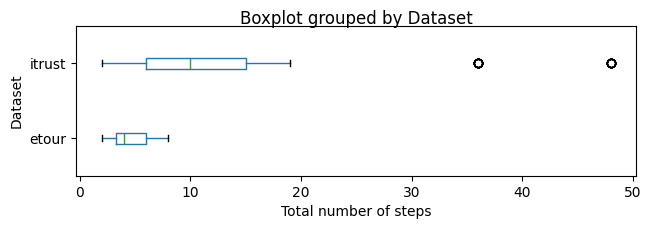

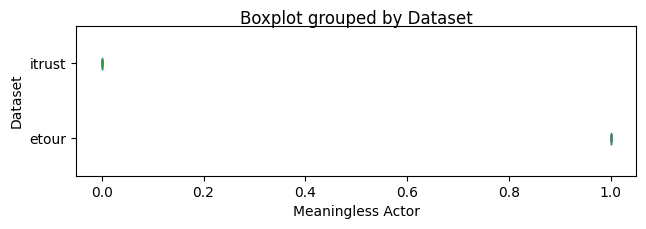

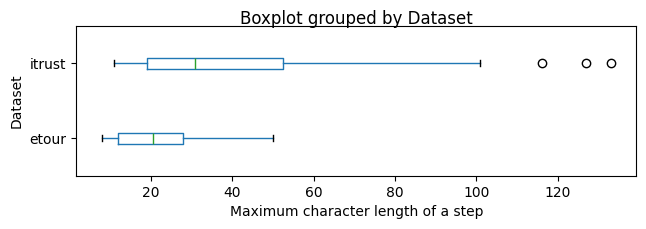

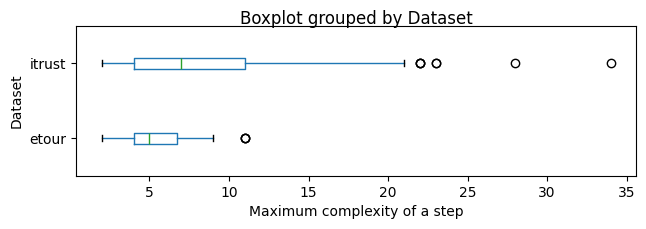

In [26]:
# Generate a horizontal box plot for each variable in the "count" category
for variable in variables["count"]:
    # create a horizontal box plot visualizing the distribution of the variable, one for each value of the Dataset column
    df.boxplot(column = variable, by = "Dataset", vert = False, showfliers = True, figsize=(7,2))

    plt.title("") # remove the title
    plt.xlabel(axis_names[variable]) # set the x-axis label
    plt.grid(False) # remove all vertical and horizontal lines

    # Save the plot in PDF format
    plt.savefig(os.path.join(PATH_FIGURES_DISTRIBUTIONS, f'{variable}.pdf'), bbox_inches='tight')
    plt.show()

### Boolean Variables

Boolean variables are categorical variables with either `True` or `False` as values.
The following code block visualizes all ratios of distributions.

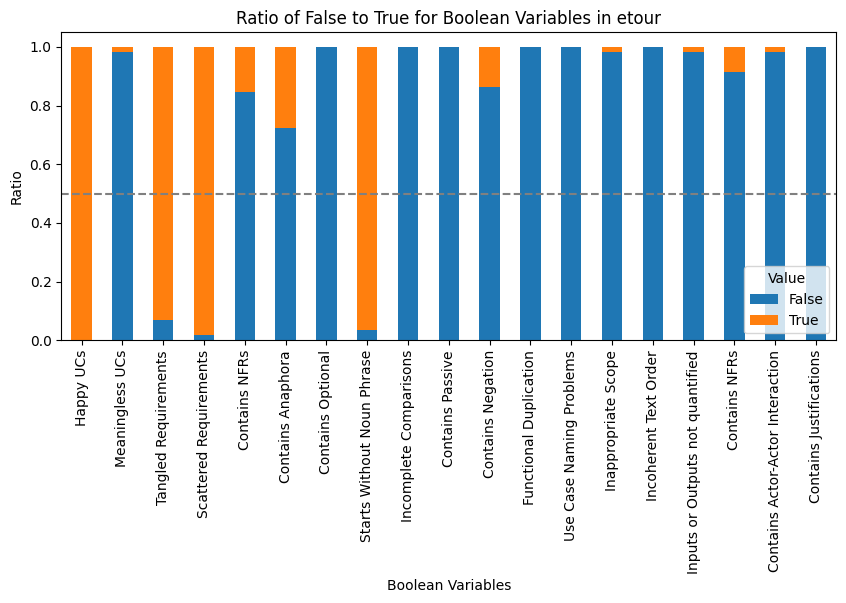

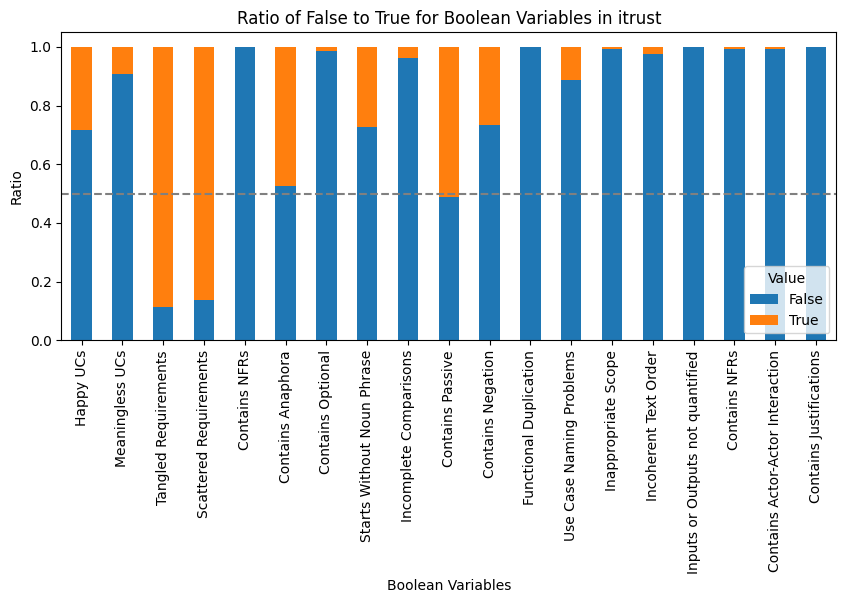

In [34]:
# Iterate over each unique value in the Dataset column
for dataset in df['Dataset'].unique():
    # Filter the dataframe for the current dataset
    df_filtered = df[df['Dataset'] == dataset]
    
    # Calculate the ratio of True to False for each boolean variable
    boolean_ratios = df_filtered[variables["boolean"]].apply(lambda x: x.value_counts(normalize=True)).T
    boolean_ratios.columns = ['False', 'True']
    
    # Plot the stacked bar chart
    boolean_ratios.plot(kind='bar', stacked=True, figsize=(10, 4))
    
    # Set the title and labels
    plt.title(f'Ratio of False to True for Boolean Variables in {dataset}')
    plt.xlabel('Boolean Variables')
    plt.ylabel('Ratio')
    plt.xticks(rotation=90)
    plt.legend(title='Value')
    plt.axhline(y=0.5, color='grey', linestyle='--')
    plt.xticks(range(len(boolean_ratios.index)), [axis_names[name] for name in boolean_ratios.index])
    
    # Save the plot in PDF format
    plt.savefig(os.path.join(PATH_FIGURES_DISTRIBUTIONS, f'boolean_ratios_{dataset}.pdf'), bbox_inches='tight')
    
    # Show the plot
    plt.show()

### Ratio Variables

Ratio variables are real values bounded in $[0, 1]$.


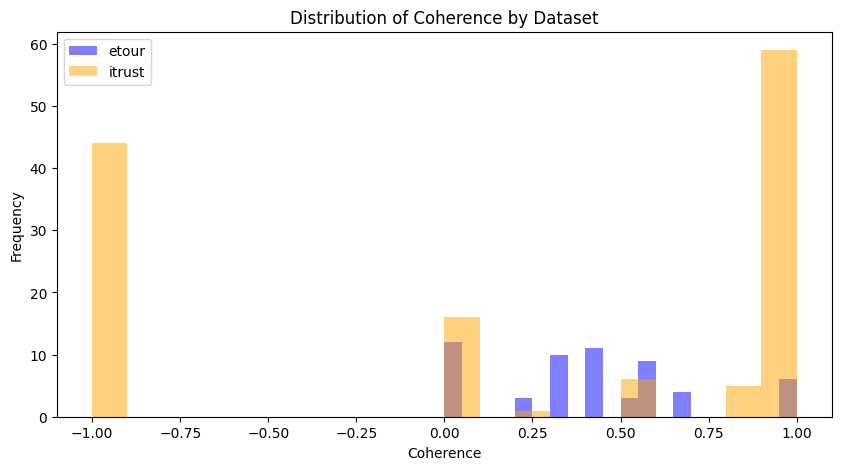

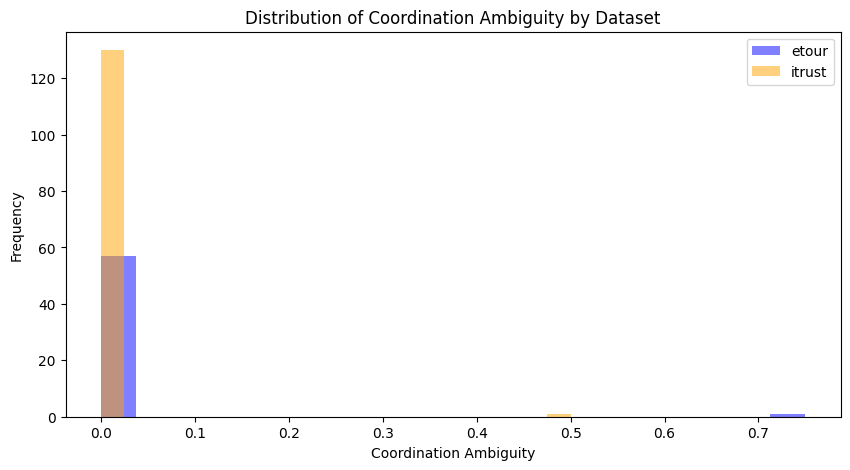

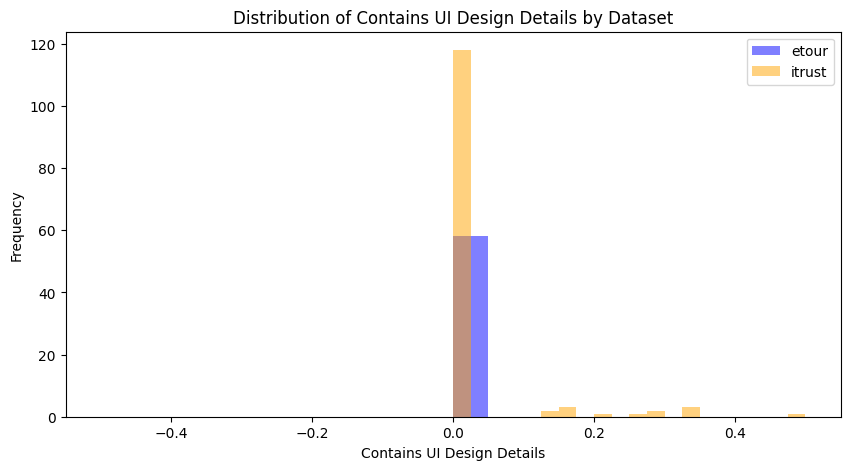

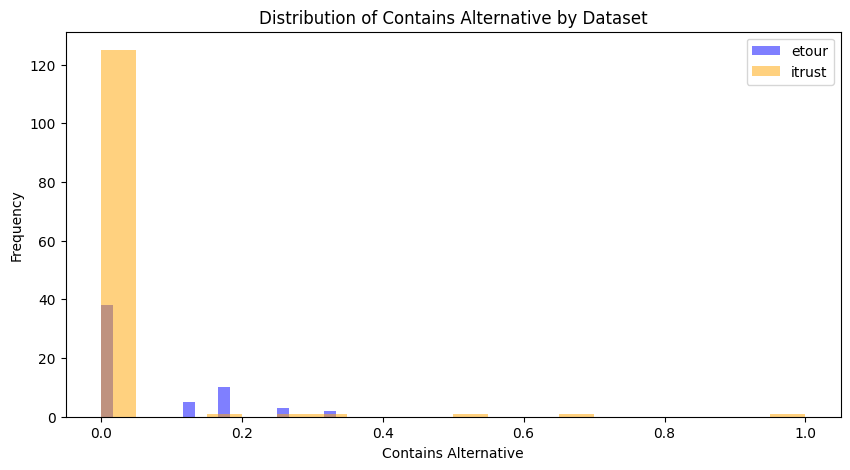

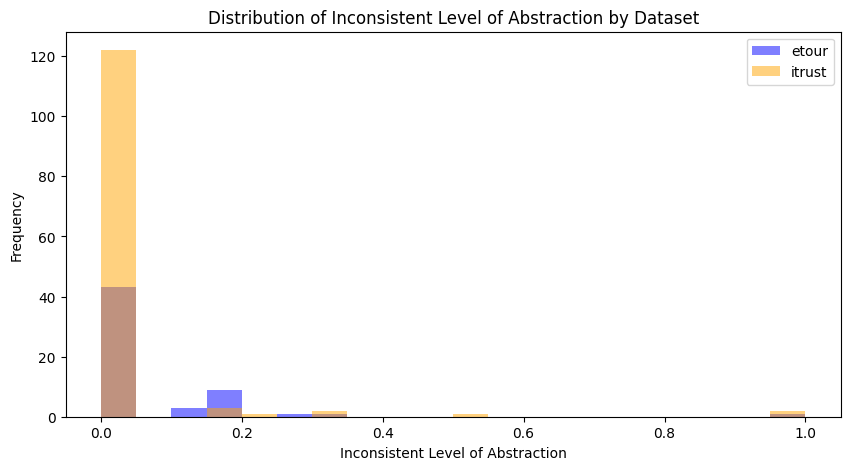

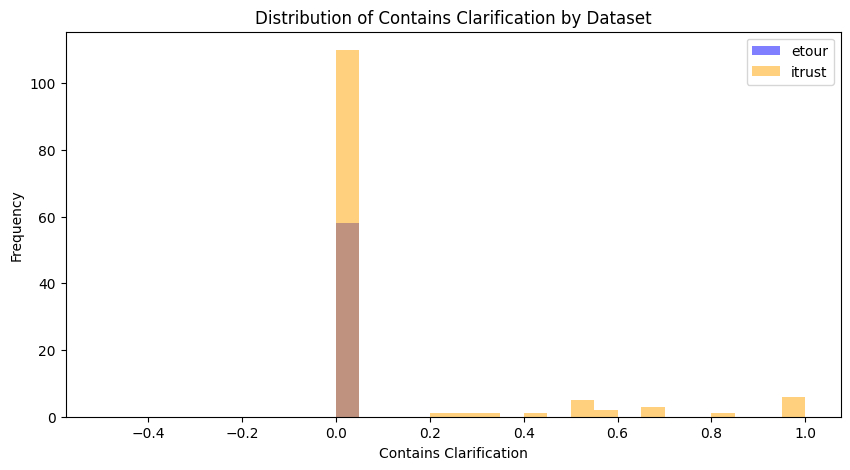

In [41]:
# Generate a histogram for each variable in the "ratio" category
for variable in variables["ratio"]:
    # Plot the histogram of the variable, one for each value of the Dataset column, with different colors in one figure
    df[df['Dataset'] == 'etour'][variable].plot(kind='hist', bins=20, alpha=0.5, color='blue', label='etour', figsize=(10, 5))
    df[df['Dataset'] == 'itrust'][variable].plot(kind='hist', bins=20, alpha=0.5, color='orange', label='itrust')

    # Set the title and labels
    plt.title(f'Distribution of {axis_names[variable]} by Dataset')
    plt.xlabel(axis_names[variable])
    plt.ylabel('Frequency')
    plt.legend()

    # Save the plot in PDF format and show the plot
    plt.savefig(os.path.join(PATH_FIGURES_DISTRIBUTIONS, f'{variable}_histogram.pdf'), bbox_inches='tight')
    plt.show()